In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../data/q1_heart_disease.csv')

In [3]:
df

,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0
...,...,...,...,...,...,...,...,...,...,...,...,...
795,60,0,asymptomatic,147.0,197.0,0,left_ventricular_hypertrophy,152,0,3.1,flat,1
796,40,1,asymptomatic,125.0,257.0,0,normal,151,0,0.7,down,0
797,45,1,asymptomatic,120.0,192.0,0,st_t_wave_abnormality,128,0,2.7,up,1
798,37,0,non_anginal,112.0,303.0,0,left_ventricular_hypertrophy,145,0,0.9,flat,0


In [4]:
print("Shape:", df.shape)

Shape: (800, 12)


In [5]:
print("\nData Types:\n", df.dtypes)


Data Types:
 age                  int64
sex                  int64
chest_pain_type     object
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg         object
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope            object
heart_disease        int64
dtype: object


In [6]:
print("\nMissing Values:\n", df.isnull().sum())


Missing Values:
 age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64


In [7]:
df.head(5)

,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


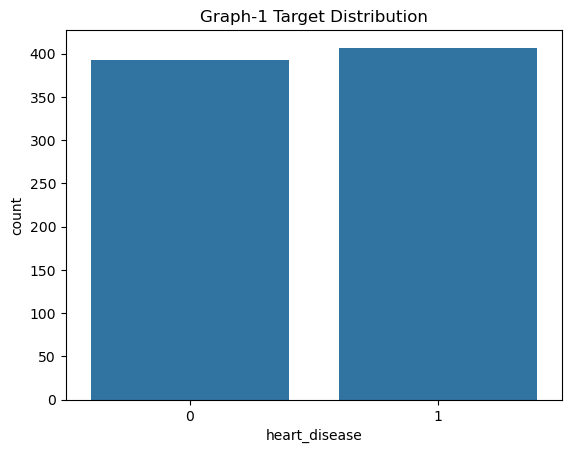

In [8]:
sns.countplot(x='heart_disease', data=df)
plt.title("Graph-1 Target Distribution")
plt.show()

Graph-1 :- The target variable (heart_disease) is approximately balanced, with nearly equal numbers of patients with and without heart disease.

This is important because balanced datasets reduce the risk of model bias toward a particular class. As a result, evaluation metrics such as F1-score and recall can be reliably used without major concern for class imbalance.

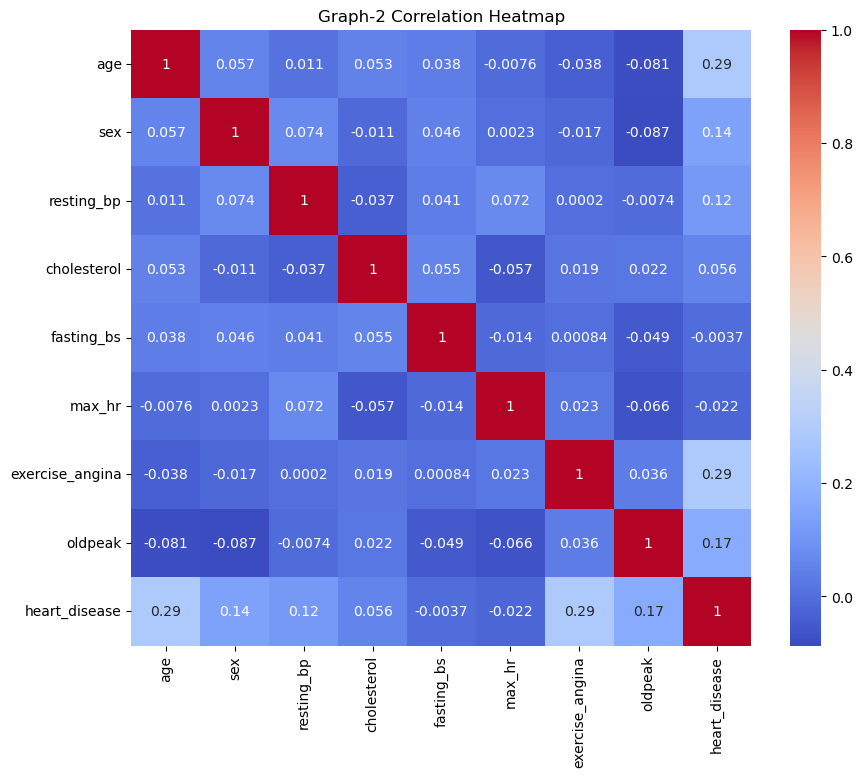

In [9]:
plt.figure(figsize=(10,8))

numeric_df = df.select_dtypes(include=['int64', 'float64'])

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

plt.title("Graph-2 Correlation Heatmap")
plt.show()

Graph 2:- The correlation heatmap shows the relationship between numerical features and the target variable (heart_disease). 
Age and exercise_angina show the strongest positive correlation (approx 0.29)with heart disease, indicating that higher age and presence of exercise-induced angina are associated with increased likelihood of heart disease. 
Oldpeak also shows a moderate positive correlation (approx 0.17), suggesting that ST depression is an important clinical indicator. 
Other features such as cholesterol and fasting blood sugar show very weak or negligible correlation with the target. 
Overall, age, exercise_angina, and oldpeak appear to be the most relevant numerical predictors for heart disease in this dataset.

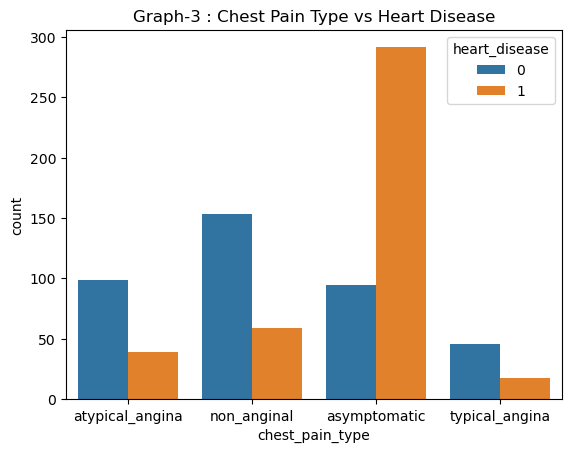

In [10]:
sns.countplot(x='chest_pain_type', hue='heart_disease', data=df)
plt.title("Graph-3 : Chest Pain Type vs Heart Disease")
plt.show()

The distribution shows a strong relationship between chest pain type and heart disease. 

Patients with asymptomatic chest pain have a significantly higher incidence of heart disease compared to other categories. 

In contrast, patients with atypical angina, non-anginal pain, and typical angina are more likely to not have heart disease. 

This indicates that chest_pain_type is a highly important categorical feature and a strong predictor of heart disease in this dataset.

In [11]:
X = df.drop('heart_disease', axis=1)
y = df['heart_disease']

In [12]:
num_cols = ['age','resting_bp','cholesterol','max_hr','oldpeak']

X[num_cols] = X[num_cols].fillna(X[num_cols].median())

Missing values in resting_bp and cholesterol were handled using median imputation. The median is preferred over the mean because it is robust to outliers and better represents the central tendency in medical datasets.

In [14]:
cat_cols = ['sex','chest_pain_type','fasting_bs','resting_ecg','exercise_angina','st_slope']

In [15]:
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [18]:
print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(640, 15) (160, 15)
heart_disease
1    0.509375
0    0.490625
Name: proportion, dtype: float64
heart_disease
1    0.50625
0    0.49375
Name: proportion, dtype: float64


In [21]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Initialize models
dt = DecisionTreeClassifier(random_state=42)
rf = RandomForestClassifier(random_state=42)
gb = GradientBoostingClassifier(random_state=42)

# Train models
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)
gb.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [22]:
from sklearn.metrics import confusion_matrix, classification_report

models = {
    "Decision Tree": dt,
    "Random Forest": rf,
    "Gradient Boosting": gb
}

for name, model in models.items():
    print(f"\n{name}")
    y_pred = model.predict(X_test)
    
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))


Decision Tree
Confusion Matrix:
 [[58 21]
 [24 57]]

Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.73      0.72        79
           1       0.73      0.70      0.72        81

    accuracy                           0.72       160
   macro avg       0.72      0.72      0.72       160
weighted avg       0.72      0.72      0.72       160


Random Forest
Confusion Matrix:
 [[59 20]
 [16 65]]

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.75      0.77        79
           1       0.76      0.80      0.78        81

    accuracy                           0.78       160
   macro avg       0.78      0.77      0.77       160
weighted avg       0.78      0.78      0.77       160


Gradient Boosting
Confusion Matrix:
 [[61 18]
 [19 62]]

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.77      0.77        79

Among the three models, the Random Forest Classifier performs best based on evaluation metrics.

It achieves the highest F1-score (0.78), indicating a strong balance between precision and recall. Additionally, it has the highest recall for the positive class (0.80), which is particularly important in medical diagnosis.

In this problem, recall is critical because false negatives (failing to identify a patient with heart disease) can have serious consequences. 

Therefore, the Random Forest model is the most suitable as it provides the best overall classification performance while minimizing the risk of missing disease cases.

In [24]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1'
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': None, 'n_estimators': 200}


In [25]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[60 19]
 [16 65]]
              precision    recall  f1-score   support

           0       0.79      0.76      0.77        79
           1       0.77      0.80      0.79        81

    accuracy                           0.78       160
   macro avg       0.78      0.78      0.78       160
weighted avg       0.78      0.78      0.78       160



Hyperparameter tuning was performed on the Random Forest model using GridSearchCV. 

The best parameters identified were n_estimators = 200 and max_depth = None, indicating that a larger number of trees and unrestricted depth provided better performance.

The tuned model shows a slight improvement in F1-score (from approximately 0.78 to 0.79), demonstrating better generalization and improved classification performance.

Overall, the tuned Random Forest model provides the most reliable predictions for this problem.